In [1]:
import pandas as pd
import csv
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

#### Definition of the size of each interval (100 ms)

In [2]:
STEP_TIME = 100

# Number of spike metric (Spikes per timestamps)

To evaluate the resulting spikes at each attack instant, the authors defined two functions: one to calculate the number of spikes and another to visualize the results, comparing attack-related activity with spontaneous activity.

In [3]:
def number_spikes(df_stimulus):
# The function first rounds the timestamp values in the given dataframe and divides them by 100 ms (the previously defined STEP_TIME). 
# Based on the results obtained, the function generates a new column called "position", which represents the timestamps on the final plot.
    df_stimulus["timestamps"] = df_stimulus["timestamps"].round(1)
    df_stimulus['position'] = 0
    df_stimulus['position'] = df_stimulus['timestamps']/STEP_TIME
    df_stimulus['position'] = df_stimulus['position'].apply(lambda x: np.floor(x))
    df_stimulus['position'] = df_stimulus['position'].astype(int)

# Secondly, the function creates another column that specifies which attack is being executed.
    ## FLO attack
    if "FLO" in df_stimulus["attack"].values:
        # Drifting gratings stimulus
        if df_stimulus['stimulus'].str.contains("Gratings", case=False).any():
            if (450 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO gray stimulus"

            elif (600 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO beginning gratings"

            elif (1600 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO during gratings"
        # Movie stimulus
        elif df_stimulus['stimulus'].str.contains("Movie", case=False).any():
            if (450 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO gray stimulus"

            elif (550 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO beginning movie"

            elif (1600 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO during movie"
        # Flash stimulus
        elif df_stimulus['stimulus'].str.contains("flash", case=False).any():
            if (625 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO during ON"

            elif (1300 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO between ON/OFF"

            elif (1875 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO during OFF" 
    ## JAM attack                
    elif "JAM" in df_stimulus["attack"].values:
        # Drifting gratings stimulus
        if df_stimulus['stimulus'].str.contains("Gratings", case=False).any():
            if (400 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM gray stimulus"

            elif (600 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM beginning gratings"

            elif (1600 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM during gratings"
        # Movie stimulus
        elif df_stimulus['stimulus'].str.contains("Movie", case=False).any():
            if (400 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM gray stimulus"

            elif (500 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM beginning movie"

            elif (1600 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM during movie"
        # Flash stimulus        
        elif df_stimulus['stimulus'].str.contains("Flash", case=False).any():
            if (600 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM during ON"

            elif (1800 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM during OFF"
            
            elif (1300 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM between ON/OFF"
    ## Normal activity
    elif "Spontaneous" in df_stimulus["attack"].values:
          df_stimulus["attack"] = "Spontaneous"

# Finally, the function counts the number of neurons for each timestamp and position, and returns the resulting dataframe.  
    df_stimulus = pd.DataFrame(df_stimulus.groupby(["attack","n_exec","timestamps","position"])["neuron_ids"].count())
    df_stimulus.reset_index(inplace=True)
    return df_stimulus

In [4]:
def combination_num_spikes(df_stimulus,df_stimulus_2,df_stimulus_3,df_spontaneous):
    # This function combines the four dataframes previously obtained using the "number_spikes" function in order to compute the number of spikes per position. 
    # The first three dataframes correspond to the attack instants of the visual stimulus, whereas the last dataframe represents spontaneous activity.
    df_combination = pd.concat([df_stimulus,df_stimulus_2,df_stimulus_3,df_spontaneous])
    df_combination['n_spikes'] = df_combination['neuron_ids']
    df_combination['position'] += 1

    # Based on the count realised in the previous function, the function aggregates the data by attack, execution number, and position,
    # computing the total number of spikes for each position. 
    df_combination = pd.DataFrame(df_combination.groupby(["attack","n_exec","position"])["n_spikes"].sum())
    df_combination.reset_index(inplace=True)

    df_combination = df_combination[df_combination['position'] != 31]

    return df_combination


#### The results obtained are plotted in the next way:

In [ ]:
def plot_num_spikes(df_comb_25,df_comb_50,stimulus):

    plt.rcParams.update({'font.family': 'monospace'})
    sns.set(style="whitegrid",font_scale=2.5, rc={'figure.figsize':(50,30)})
    plt.rcParams['axes.edgecolor'] = "black" #set the value globally

    label_size = 80
    ticks_size = 80
    legend_size = 60
    line_size = 60

    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(75, 25), gridspec_kw={'width_ratios': [1, 1]})

    # Flash plot
    if "flash" in stimulus:
        # FLO
        if (df_comb_25['attack'].str.contains("FLO", case=False).any()) & (df_comb_50['attack'].str.contains("FLO", case=False).any()):
            ## FIRST PLOT
            sns.pointplot(x="position", y="n_spikes", data= df_comb_25,  palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['FLO during ON','FLO between ON/OFF','FLO during OFF','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax1, dodge=True)
            ## SECOND PLOT
            sns.pointplot(x="position", y="n_spikes", data= df_comb_50, palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['FLO during ON','FLO between ON/OFF','FLO during OFF','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax2, dodge=True)

            for ax in (ax1, ax2):
                ymin, ymax = ax.get_ylim()
                ymin_extended = ymin - 0.1 * (ymax - ymin)  
                ymax_extended = ymax + 100 * (ymax - ymin) 
                ## Gray shades
                for x_start in [5.7, 12.7, 17.7]:
                    ax.axvspan(x_start, x_start + 0.6, color="grey", alpha=0.4)
                    ax.vlines([x_start, x_start + 0.6], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2)
                ## Red numbers
                for i, x in enumerate([6.0, 13.0, 18.0], 1):
                    ax.text(x, 170000, str(i), ha='center', va='center', fontsize=ticks_size, color='red', fontweight='bold')
        # JAM
        else:
            ## FIRST PLOT
            sns.pointplot(x="position", y="n_spikes", data= df_comb_25,  palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['JAM during ON','JAM between ON/OFF','JAM during OFF','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax1, dodge=True, zorder=3)
            ## SECOND PLOT      
            sns.pointplot(x="position", y="n_spikes", data= df_comb_50,  palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['JAM during ON','JAM between ON/OFF','JAM during OFF','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax2, dodge=True, zorder=3)

            for ax in (ax1, ax2):
                ymin, ymax = ax.get_ylim()
                ymin_extended = ymin - 0.1 * (ymax - ymin)  
                ymax_extended = ymax + 100 * (ymax - ymin)
                ## Gray shades 
                for x_start in [5.5, 12.5, 17.5]:
                    ax.axvspan(x_start, x_start + 1, color="grey", alpha=0.4)
                    ax.vlines([x_start, x_start + 1], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2)
                ## Red numbers
                for i, x in enumerate([6.0, 13.0, 18.0], 1):
                    ax.text(x, 110000, str(i), ha='center', va='center', fontsize=ticks_size, color='red', fontweight='bold')
    
    # Drifting gratings plot
    elif "gratings" in stimulus:
        # FLO
        if (df_comb_25['attack'].str.contains("FLO", case=False).any()) & (df_comb_50['attack'].str.contains("FLO", case=False).any()):
            ## FIRST PLOT
            sns.pointplot(x="position", y="n_spikes", data= df_comb_25, palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['FLO gray stimulus','FLO beginning gratings','FLO during gratings','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax1, dodge=True)
            ## SECOND PLOT
            sns.pointplot(x="position", y="n_spikes", data= df_comb_50, palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['FLO gray stimulus','FLO beginning gratings','FLO during gratings','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax2, dodge=True)

            for ax in (ax1, ax2):
                ymin, ymax = ax.get_ylim()
                ymin_extended = ymin - 0.1 * (ymax - ymin)  
                ymax_extended = ymax + 100 * (ymax - ymin)
                ## Gray shades  
                for x_start in [3.7, 5.7, 15.7]:
                    ax.axvspan(x_start, x_start + 0.6, color="grey", alpha=0.4)
                    ax.vlines([x_start, x_start + 0.6], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2)
                ## Red numbers
                for i, x in enumerate([4.0, 6.0, 16.0], 1):
                    ax.text(x, 170000, str(i), ha='center', va='center', fontsize=ticks_size, color='red', fontweight='bold')
        # JAM
        else:
            ## FIRST PLOT
            sns.pointplot(x="position", y="n_spikes", data= df_comb_25,  palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['JAM gray stimulus','JAM beginning gratings','JAM during gratings','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax1, dodge=True, zorder=3)
            ## SECOND PLOT
            sns.pointplot(x="position", y="n_spikes", data= df_comb_50,  palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['JAM gray stimulus','JAM beginning gratings','JAM during gratings','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax2, dodge=True, zorder=3)

            for ax in (ax1, ax2):
                ymin, ymax = ax.get_ylim()
                ymin_extended = ymin - 0.1 * (ymax - ymin)  
                ymax_extended = ymax + 100 * (ymax - ymin)
                ## Gray shades 
                for x_start in [3.5, 5.5, 15.5]:
                    ax.axvspan(x_start, x_start + 1, color="grey", alpha=0.4)
                    ax.vlines([x_start, x_start + 1], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2)
                ## Red numbers
                for i, x in enumerate([4.0, 6.0, 16.0], 1):
                    ax.text(x, 110000, str(i), ha='center', va='center', fontsize=ticks_size, color='red', fontweight='bold')
    
    # Movie plot
    elif "movie" in stimulus:
        # FLO
        if (df_comb_25['attack'].str.contains("FLO", case=False).any()) & (df_comb_50['attack'].str.contains("FLO", case=False).any()):
            ## FIRST PLOT
            sns.pointplot(x="position", y="n_spikes", data= df_comb_25, palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['FLO gray stimulus','FLO beginning movie','FLO during movie','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax1, dodge=True)
            ## SECOND PLOT
            sns.pointplot(x="position", y="n_spikes", data= df_comb_50, palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['FLO gray stimulus','FLO beginning movie','FLO during movie','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax2, dodge=True)

            for ax in (ax1, ax2):
                ymin, ymax = ax.get_ylim()
                ymin_extended = ymin - 0.1 * (ymax - ymin)  
                ymax_extended = ymax + 100 * (ymax - ymin)
                ## Gray shades  
                for x_start in [3.7, 4.7, 15.7]:
                    ax.axvspan(x_start, x_start + 0.6, color="grey", alpha=0.4)
                    ax.vlines([x_start, x_start + 0.6], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2)
                ## Red numbers
                for i, x in enumerate([4.0, 5.0, 16.0], 1):
                    ax.text(x, 174000, str(i), ha='center', va='center', fontsize=ticks_size, color='red', fontweight='bold')
        # JAM
        else:
            ## FIRST PLOT
            sns.pointplot(x="position", y="n_spikes", data= df_comb_25,  palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['JAM gray stimulus','JAM beginning movie','JAM during movie','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax1, dodge=True, zorder=3)
            ## SECOND PLOT
            sns.pointplot(x="position", y="n_spikes", data= df_comb_50,  palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['JAM gray stimulus','JAM beginning movie','JAM during movie','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax2, dodge=True, zorder=3)

            for ax in (ax1, ax2):
                ymin, ymax = ax.get_ylim()
                ymin_extended = ymin - 0.1 * (ymax - ymin)  
                ymax_extended = ymax + 100 * (ymax - ymin)
                ## Gray shades  
                for x_start in [3.5, 4.5, 15.5]:
                    ax.axvspan(x_start, x_start + 1, color="grey", alpha=0.4)
                    ax.vlines([x_start, x_start + 1], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2)
                ## Red numbers
                for i, x in enumerate([4.0, 5.0, 16.0], 1):
                    ax.text(x, 110000, str(i), ha='center', va='center', fontsize=ticks_size, color='red', fontweight='bold')
    
    # Axis parameters 
    for ax in (ax1, ax2):
        ax.tick_params(labelsize=ticks_size)
        # Setting x and y axis
        ## For FLO plots
        ax.set_ylim(0, 180000)
        ## For JAM plots
        ax.set_ylim(-3000, 120000)
        ax.yaxis.set_major_locator(MultipleLocator(20000))
        ax.set_xlim(-1, 30)     
        ax.xaxis.set_major_locator(MultipleLocator(1))

        ax.set_xlabel('') 
        ax.set_ylabel('')

        for label in ax.get_xticklabels():
            label.set_rotation(70)
        for label in ax.get_yticklabels():
            label.set_rotation(50)
        ax.xaxis.grid(True)  

        # Setting legend labels
        gray_line_legend = Line2D([0], [0], color='grey', lw=25, alpha=0.4, label='Under attack')
        handles, labels = ax.get_legend_handles_labels()

        handles.append(gray_line_legend)
        labels.append('Under attack')
        
        leg = ax.legend(handles=handles, labels=labels, loc='best', fancybox=True, shadow=True, ncol=1, frameon=True, fontsize=legend_size)
        leg.get_frame().set_edgecolor('black')

    # Setting plot labels
    fig.text(0.53, -0.03, 'Time interval', ha='center', fontsize=label_size, fontweight='bold')
    ax1.set_ylabel("Number of spikes", fontsize=label_size, fontweight="bold")
    
    # The plot created is saved as a PDF file to improve the visualization. 
    plt.tight_layout()
    plt.savefig("./Figure7a.pdf", bbox_inches='tight')

# Use case of number of spikes

In [ ]:
# Attack instants of flash effect (25% of the neurons).
df_stimulus_25 = pd.read_csv("./Flash/output_FLO_625ms_quarternum_Vth_flash_trial_9_BKG_trial_99_10exec/spikes.csv", delimiter=";") 
df_stimulus2_25 = pd.read_csv("./Flash/output_FLO_1300ms_quarternum_Vth_flash_trial_9_BKG_trial_99_10exec/spikes.csv", delimiter=";")
df_stimulus3_25 = pd.read_csv("./Flash/output_FLO_1875ms_quarternum_Vth_flash_trial_9_BKG_trial_99_10exec/spikes.csv", delimiter=";")
# Normal activity of flash stimulus.
df_spontaneous = pd.read_csv("./Spontaneous/output_flash_h5_trial_9_BKG_trial_99/spikes.csv", delimiter=";")

df_stimulus_25 = number_spikes(df_stimulus_25)
df_stimulus2_25 = number_spikes(df_stimulus2_25)
df_stimulus3_25 = number_spikes(df_stimulus3_25)
df_spontaneous = number_spikes(df_spontaneous)

df_comb_25 = combination_num_spikes(df_stimulus_25,df_stimulus2_25,df_stimulus3_25,df_spontaneous)

In [ ]:
# Attack instants of flash effect (50% of the neurons).
df_stimulus_50 = pd.read_csv("./Flash/output_FLO_625ms_halfnum_Vth_flash_trial_9_BKG_trial_99_10exec/spikes.csv", delimiter=";") 
df_stimulus2_50 = pd.read_csv("./Flash/output_FLO_1300ms_halfnum_Vth_flash_trial_9_BKG_trial_99_10exec/spikes.csv", delimiter=";")
df_stimulus3_50 = pd.read_csv("./Flash/output_FLO_1875ms_halfnum_Vth_flash_trial_9_BKG_trial_99_10exec/spikes.csv", delimiter=";")

df_stimulus_50 = number_spikes(df_stimulus_50)
df_stimulus2_50 = number_spikes(df_stimulus2_50)
df_stimulus3_50 = number_spikes(df_stimulus3_50)

df_comb_50 = combination_num_spikes(df_stimulus_50,df_stimulus2_50,df_stimulus3_50,df_spontaneous)

/tmp/ipykernel_2944/3636990312.py:19: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(x="position", y="n_spikes", data= df_comb_25,  palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['FLO during ON','FLO between ON/OFF','FLO during OFF','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax1, dodge=True)
/tmp/ipykernel_2944/3636990312.py:19: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 10.0}` instead.

  sns.pointplot(x="position", y="n_spikes", data= df_comb_25,  palette=['#0173b2', '#cc78bc', '#029e73','#de8f05'], hue="attack", hue_order=['FLO during ON','FLO between ON/OFF','FLO during OFF','Spontaneous'], errorbar="sd",errwidth=10.0,scale=3.2, ax=ax1, dodge=True)
/tmp/ipykernel_2944/3636990312.py:21: 

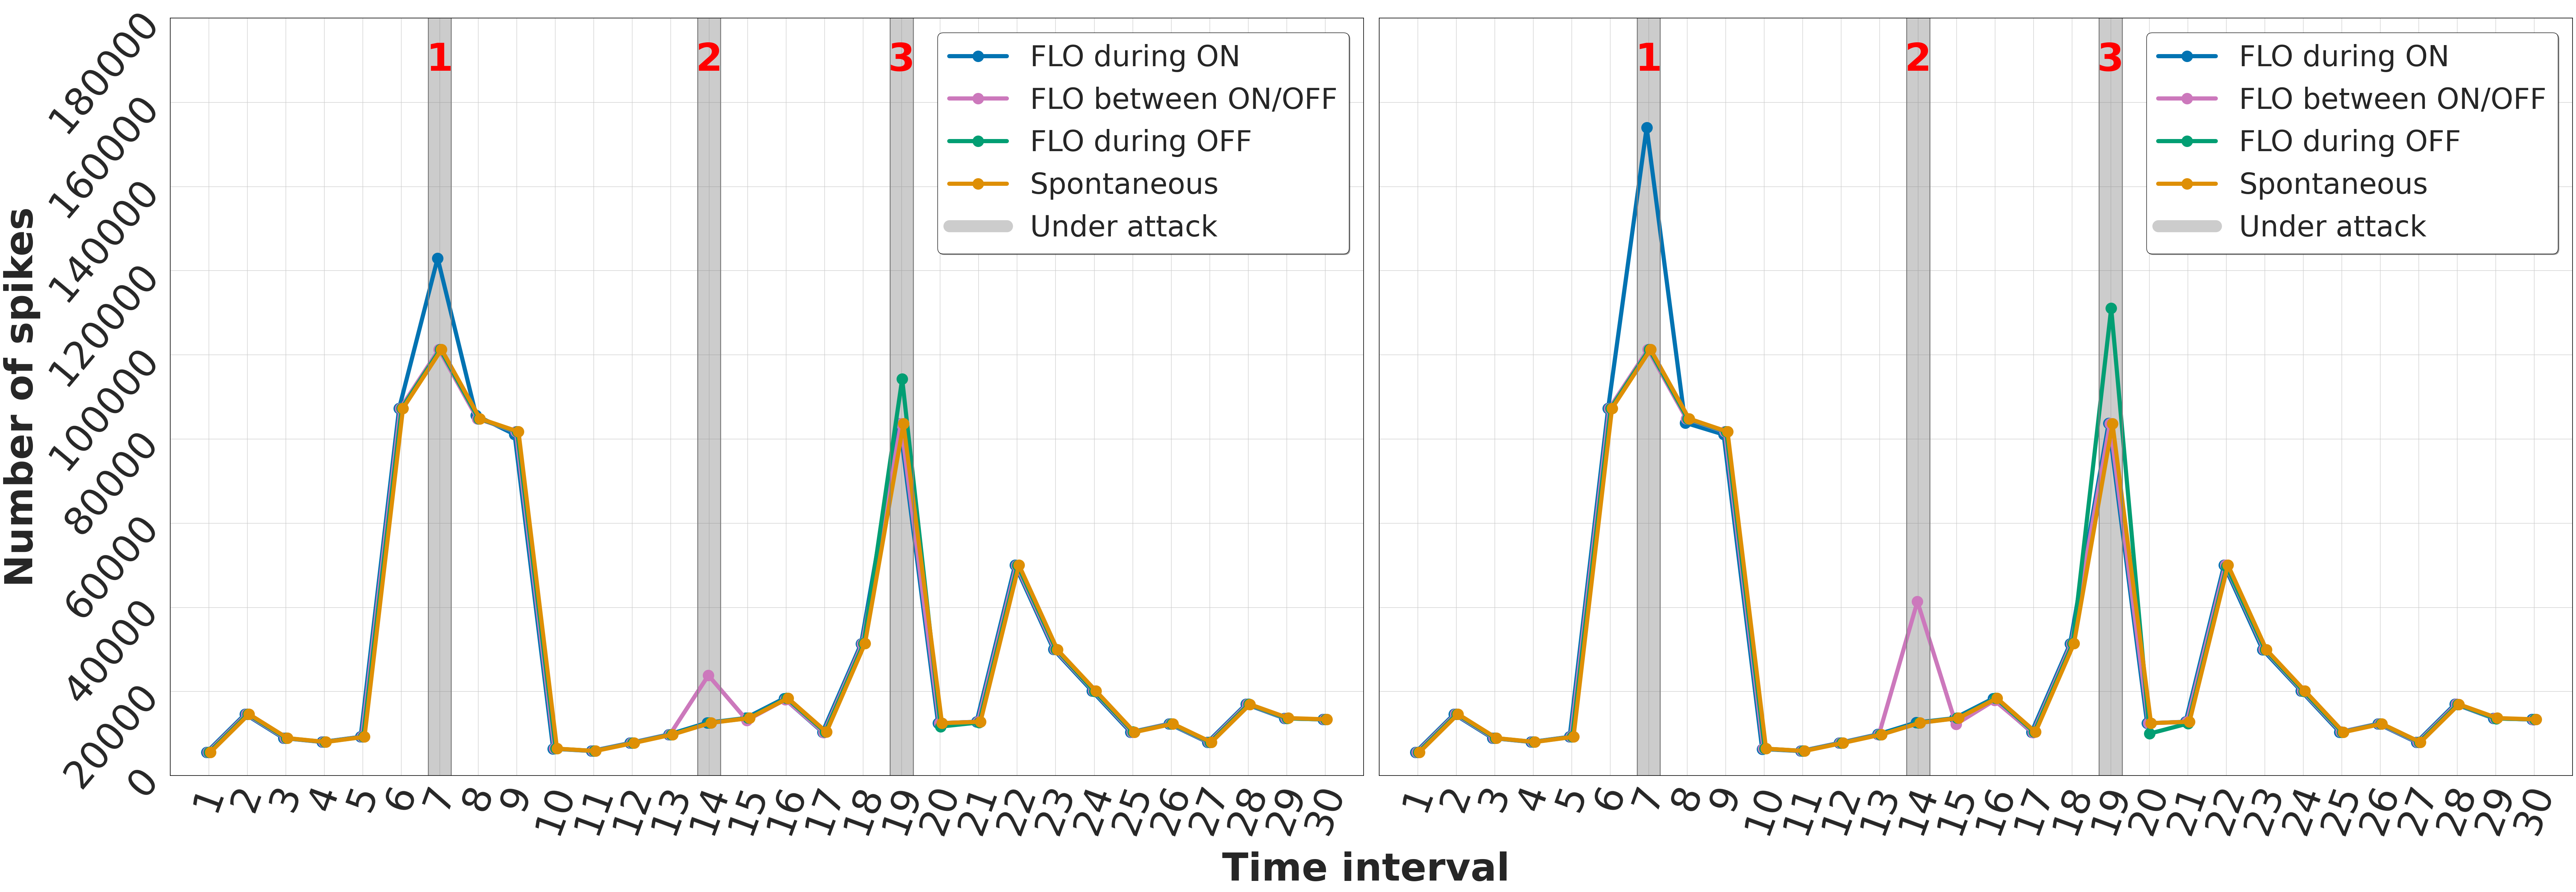

In [15]:
plot_num_spikes(df_comb_25,df_comb_50,"flash")

# Percentage of shifts metric (Delay of spikes in time compared to spontaneous behavior)

As the previous metric, the authors create two functions. The first function is responsible for calculating the delay of each attack instant compared to the spontaneous activity per interval. In contrast, the second function handles the visual representation of the results. 

In [3]:
def percentage_shift_per_instant(df_stimulus, df_spontaneous):
    # The function first rounds the timestamp values in the given dataframes (attack and spontaneous activity) and divides them by 100 ms (the previously defined STEP_TIME). 
    # Based on the results obtained, the function generates a new column called "position", which represents the timestamps on the final plot.
    df_stimulus['position'] = 0
    df_stimulus['position'] = df_stimulus['timestamps']/STEP_TIME
    df_stimulus['position'] = df_stimulus['position'].apply(lambda x: np.floor(x))
    df_stimulus['position'] = df_stimulus['position'].astype(int)
    df_stimulus['position'] += 1

    df_spontaneous['position'] = 0
    df_spontaneous['position'] = df_spontaneous['timestamps']/STEP_TIME
    df_spontaneous['position'] = df_spontaneous['position'].apply(lambda x: np.floor(x))
    df_spontaneous['position'] = df_spontaneous['position'].astype(int)
    df_spontaneous['position'] += 1

    # Secondly, the function creates another column that specifies which attack is being executed.
    ## FLO attack
    if "FLO" in df_stimulus["attack"].values:
        # Drifting gratings stimulus
        if df_stimulus['stimulus'].str.contains("Gratings", case=False).any():
            if (450 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO gray stimulus"

            elif (600 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO beginning gratings"

            elif (1600 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO during gratings"
        # Movie stimulus
        elif df_stimulus['stimulus'].str.contains("Movie", case=False).any():
            if (450 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO gray stimulus"

            elif (550 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO beginning movie"

            elif (1600 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO during movie"
        # Flash stimulus        
        elif df_stimulus['stimulus'].str.contains("Flash", case=False).any():

            if (625 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO during ON"

            elif (1300 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO between ON/OFF"

            elif (1875 in df_stimulus['instant_attack'].values):
                df_stimulus["attack"] = "FLO during OFF" 
    ## JAM attack                
    elif "JAM" in df_stimulus["attack"].values:
        # Drifting gratings stimulus
        if df_stimulus['stimulus'].str.contains("Gratings", case=False).any():
            if (400 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM gray stimulus"

            elif (600 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM beginning gratings"

            elif (1600 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM during gratings"
        # Movie stimulus
        elif df_stimulus['stimulus'].str.contains("Movie", case=False).any():
            if (400 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM gray stimulus"

            elif (500 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM beginning movie"

            elif (1600 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM during movie"
        # Flash stimulus        
        elif df_stimulus['stimulus'].str.contains("Flash", case=False).any():
            if (600 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM during ON"

            elif (1300 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM between ON/OFF"

            elif (1800 in df_stimulus['init_attack'].values):
                df_stimulus["attack"] = "JAM during OFF"
    
    # Thirdly, the function follows the next steps to obtain the percentage of spikes that do not coincide:

    # Merge the stimulus and spontaneous dataframes on the columns 'timestamps', 'neuron_ids', and 'position'.
    # This merge includes all rows from the stimulus dataframe and only matching rows from the spontaneous dataframe.
    # Rows with no match in the spontaneous dataframe have their values replaced with 0.
    join_attack_shifts = pd.merge(df_stimulus, df_spontaneous, how='left', left_on=["timestamps", "neuron_ids", "position"], right_on=["timestamps", "neuron_ids", "position"])
    join_attack_shifts = join_attack_shifts.fillna(0)

    # Filter the rows where the column 'attack_y' is 0, which indicates spikes that do not coincide with the spontaneous data.
    filtered_shifts = join_attack_shifts[join_attack_shifts['attack_y'] == 0]

    # Group the filtered data by 'attack_x', 'n_exec_x', and 'position', counting the number of unique 'neuron_ids' per group to obtain the number of shifts of the attack.
    n_shifts_attack = pd.DataFrame(filtered_shifts.groupby(["attack_x", "n_exec_x", "position"])["neuron_ids"].count())
    n_shifts_attack.reset_index(inplace=True)

    # Group the stimulus data by 'n_exec' and 'position', counting the number of unique 'neuron_ids' per group to obtain the number of spikes of the attack.
    attack_nSpikes = pd.DataFrame(df_stimulus.groupby(["n_exec", "position"])["neuron_ids"].count())
    attack_nSpikes.reset_index(inplace=True)

    # Rename columns in both dataframes to make the subsequent merge operation more intuitive.
    n_shifts_attack.rename(columns={'neuron_ids': 'n_shifts_count'}, inplace=True)
    attack_nSpikes.rename(columns={'neuron_ids': 'n_spikes_count'}, inplace=True)

    # Merge the two dataframes based on 'n_exec' and 'position' to compute the percentage of non-coinciding spikes per position.
    percent_shifts_attack = pd.merge(n_shifts_attack, attack_nSpikes, left_on=["n_exec_x", "position"], right_on=["n_exec", "position"], how='left')

    # Calculate the percentage of spikes that do not coincide.
    # This is computed as the count of shifts divided by the total number of spikes, multiplied by 100.
    percent_shifts_attack['percent_shifts'] = round((percent_shifts_attack['n_shifts_count'] / percent_shifts_attack['n_spikes_count']) * 100, 2)

    # Select only the necessary columns for further processing.
    percent_shifts_attack = percent_shifts_attack[['attack_x', 'n_exec_x', 'position', 'percent_shifts']]

    # Generate all possible combinations of 'attack', 'n_exec', and 'position' for a complete result set.   
    all_n_exec = df_stimulus['n_exec'].unique()
    all_attack = df_stimulus['attack'].unique()
    all_positions = range(1, 31)
    all_combinations = pd.MultiIndex.from_product([all_attack, all_n_exec, all_positions], names=['attack','n_exec', 'position']).to_frame(index=False)

    # Merge the computed percentages with the complete list of combinations to ensure all cases are represented.
    percent_shifts_attack = pd.merge(all_combinations, percent_shifts_attack, left_on=['attack','n_exec', 'position'], right_on=['attack_x','n_exec_x', 'position'], how='left')

    # Replace NaN values in the percentage column with 0 to handle missing data.
    percent_shifts_attack = percent_shifts_attack.fillna(0)

    # Select the final required columns and reset the index to produce the result dataframe.
    result_dataframe = percent_shifts_attack[['attack','n_exec', 'position', 'percent_shifts']]
    result_dataframe.reset_index(drop=True, inplace=True)

    # Replace percentages of 0.00 with NaN for clarity in the output and reset the index again.
    result_dataframe.loc[:, 'percent_shifts'] = result_dataframe['percent_shifts'].replace(0.00, np.nan)
    result_dataframe.reset_index(drop=True, inplace=True)

    return result_dataframe

In [4]:
def combination_percentage_shift_per_instant(df_stimulus,df_stimulus_2,df_stimulus_3):
    # This function combines the three dataframes previously obtained using the "percentage_shift_per_instant" function to represent the results visually. 
    df_combination = pd.concat([df_stimulus,df_stimulus_2,df_stimulus_3])
    df_combination.reset_index(drop=True, inplace=True)
    return df_combination

#### The results obtained are plotted in the next way:

In [ ]:
def plot_percentage_shift_per_instant(df_comb_25,df_comb_50,stimulus):
    plt.rcParams.update({'font.family': 'monospace'})
    sns.set(style="whitegrid",font_scale=2.5, rc={'figure.figsize':(75, 25)})
    plt.rcParams['axes.edgecolor'] = "black" #set the value globally

    label_size = 80
    ticks_size = 80
    legend_size = 60
    line_size = 60

    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(75, 25), gridspec_kw={'width_ratios': [1, 1]})
    # Flash plot
    if "flash" in stimulus:
        # FLO
        if (df_comb_25['attack'].str.contains("FLO", case=False).any()) & (df_comb_50['attack'].str.contains("FLO", case=False).any()):
            ## FIRST PLOT
            sns.barplot(x="position", y="percent_shifts", data= df_comb_25,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['FLO during ON','FLO between ON/OFF','FLO during OFF'],errorbar="sd", errwidth=10.0,  ax=ax1, width=0.9)
            ## SECOND PLOT
            sns.barplot(x="position", y="percent_shifts", data= df_comb_50,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['FLO during ON','FLO between ON/OFF','FLO during OFF'],errorbar="sd", errwidth=10.0,  ax=ax2, width=0.9)
        # JAM
        else:
            ## FIRST PLOT
            sns.barplot(x="position", y="percent_shifts", data= df_comb_25,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['JAM during ON','JAM between ON/OFF','JAM during OFF'], errorbar="sd", errwidth=10.0, ax=ax1, width=0.9)
            ## SECOND PLOT
            sns.barplot(x="position", y="percent_shifts", data= df_comb_50,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['JAM during ON','JAM between ON/OFF','JAM during OFF'], errorbar="sd", errwidth=10.0, ax=ax2, width=0.9)

        for ax in (ax1, ax2):
            ymin, ymax = ax.get_ylim()
            ymin_extended = ymin - 0.1 * (ymax - ymin)  
            ymax_extended = ymax + 100 * (ymax - ymin)
            ## Gray shades 
            for x_start in [5.5, 12.5, 17.5]:
                ax.axvspan(x_start, x_start + 1, color="grey", alpha=0.4)
                ax.vlines([x_start, x_start + 1], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2)
            ## Red numbers
            for i, x in enumerate([6.0, 13.0, 18.0], 1):
                ax.text(x, 104, str(i), ha='center', va='center', fontsize=ticks_size, color='red', fontweight='bold')
    
    # Drifting gratings plot
    elif "gratings" in stimulus:
        # FLO
        if (df_comb_25['attack'].str.contains("FLO", case=False).any()) & (df_comb_50['attack'].str.contains("FLO", case=False).any()):
            ## FIRST PLOT
            sns.barplot(x="position", y="percent_shifts", data= df_comb_25,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['FLO gray stimulus','FLO beginning gratings','FLO during gratings'], errorbar="sd", errwidth=10.0, ax=ax1, width=0.9)
            ## SECOND PLOT
            sns.barplot(x="position", y="percent_shifts", data= df_comb_50,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['FLO gray stimulus','FLO beginning gratings','FLO during gratings'], errorbar="sd", errwidth=10.0, ax=ax2, width=0.9)
        # JAM
        else:
            ## FIRST PLOT
            sns.barplot(x="position", y="percent_shifts", data= df_comb_25,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['JAM gray stimulus','JAM beginning gratings','JAM during gratings'], errorbar="sd", errwidth=10.0, ax=ax1, width=0.9)
            ## SECOND PLOT
            sns.barplot(x="position", y="percent_shifts", data= df_comb_50,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['JAM gray stimulus','JAM beginning gratings','JAM during gratings'], errorbar="sd", errwidth=10.0, ax=ax2, width=0.9)

        for ax in (ax1, ax2):
            ymin, ymax = ax.get_ylim()
            ymin_extended = ymin - 0.1 * (ymax - ymin)  
            ymax_extended = ymax + 100 * (ymax - ymin)
            ## Gray shades 
            for x_start in [3.5, 5.5, 15.5]:
                ax.axvspan(x_start, x_start + 1, color="grey", alpha=0.4)
                ax.vlines([x_start, x_start + 1], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2)
            ## Red numbers
            for i, x in enumerate([4.0, 6.0, 16.0], 1):
                ax.text(x, 104, str(i), ha='center', va='center', fontsize=ticks_size, color='red', fontweight='bold')
        
    # Movie plot
    elif "movie" in stimulus:
        # FLO
        if (df_comb_25['attack'].str.contains("FLO", case=False).any()) & (df_comb_50['attack'].str.contains("FLO", case=False).any()):
            ## FIRST PLOT
            sns.barplot(x="position", y="percent_shifts", data= df_comb_25,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['FLO gray stimulus','FLO beginning movie','FLO during movie'], errorbar="sd", errwidth=10.0, ax=ax1, width=0.9)
            ## SECOND PLOT
            sns.barplot(x="position", y="percent_shifts", data= df_comb_50,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['FLO gray stimulus','FLO beginning movie','FLO during movie'], errorbar="sd", errwidth=10.0, ax=ax2, width=0.9)
        # JAM
        else:
            ## FIRST PLOT
            sns.barplot(x="position", y="percent_shifts", data= df_comb_25,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['JAM gray stimulus','JAM beginning movie','JAM during movie'], errorbar="sd", errwidth=10.0, ax=ax1, width=0.9)
            ## SECOND PLOT
            sns.barplot(x="position", y="percent_shifts", data= df_comb_50,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['JAM gray stimulus','JAM beginning movie','JAM during movie'], errorbar="sd", errwidth=10.0, ax=ax2, width=0.9)

        for ax in (ax1, ax2):
            ymin, ymax = ax.get_ylim()
            ymin_extended = ymin - 0.1 * (ymax - ymin)  
            ymax_extended = ymax + 100 * (ymax - ymin)
            ## Gray shades 
            for x_start in [3.5, 4.5, 15.5]:
                ax.axvspan(x_start, x_start + 1, color="grey", alpha=0.4)
                ax.vlines([x_start, x_start + 1], ymin=ymin_extended, ymax=ymax_extended, color="grey", linewidth=2)
            ## Red numbers
            for i, x in enumerate([4.0, 5.0, 16.0], 1):
                ax.text(x, 104, str(i), ha='center', va='center', fontsize=ticks_size, color='red', fontweight='bold')
    
    # Axis parameters 
    for ax in (ax1, ax2):
        # Setting x and y axis
        ax.set_ylim(0, 110)
        ax.yaxis.set_major_locator(MultipleLocator(20))
        ax.set_xlim(-1, 30)     
        ax.xaxis.set_major_locator(MultipleLocator(1))

        ax.set_xlabel('')  
        ax.set_ylabel('')

        for label in ax.get_xticklabels():
            label.set_rotation(70)
        for label in ax.get_yticklabels():
            label.set_rotation(50)
        ax.xaxis.grid(True)
        ax.tick_params(labelsize=ticks_size)  

        # Setting legend labels
        gray_line_legend = Line2D([0], [0], color='grey', lw=25, alpha=0.4, label='Under attack')
        handles, labels = ax.get_legend_handles_labels()

        handles.append(gray_line_legend)
        labels.append('Under attack')
        
        leg = ax.legend(handles=handles, labels=labels, loc='lower right', fancybox=True, shadow=True, ncol=1, frameon=True, fontsize=legend_size)
        leg.get_frame().set_edgecolor('black')

        # Setting plot labels
        fig.text(0.53, -0.03, 'Time interval', ha='center', fontsize=label_size, fontweight='bold')
        ax.set_ylabel("Shift percentage per interval", fontsize=label_size, fontweight="bold")

    # The plot created is saved as a PDF file to improve the visualization.
    plt.tight_layout()
    plt.savefig("./Figure12b.pdf", bbox_inches='tight')
   

# Use case of shifts analysis

In [ ]:
# Attack instants of drifting gratings stimulus (25% of the neurons).
df_stimulus_25 = pd.read_csv("./Gratings/output_JAM_400_500ms_quarternum_Vth_gratings_ori90.0_trial_9_BKG_trial_29_10exec/spikes.csv", delimiter=";")
df_stimulus2_25 = pd.read_csv("./Gratings/output_JAM_600_700ms_quarternum_Vth_gratings_ori90.0_trial_9_BKG_trial_29_10exec/spikes.csv", delimiter=";")
df_stimulus3_25 = pd.read_csv("./Gratings/output_JAM_1600_1700ms_quarternum_Vth_gratings_ori90.0_trial_9_BKG_trial_29_10exec/spikes.csv", delimiter=";")
# Normal activity of drifting gratings stimulus.
df_spontaneous = pd.read_csv("./Spontaneous/output_gratings_ori90.0_h5_trial_9_BKG_trial_29/spikes.csv", delimiter=";")

df_stimulus_25 = percentage_shift_per_instant(df_stimulus_25, df_spontaneous)
df_stimulus2_25 = percentage_shift_per_instant(df_stimulus2_25, df_spontaneous)
df_stimulus3_25 = percentage_shift_per_instant(df_stimulus3_25, df_spontaneous)

df_shift_25 = combination_percentage_shift_per_instant(df_stimulus_25,df_stimulus2_25,df_stimulus3_25)

In [ ]:
# Attack instants of drifting gratings stimulus (50% of the neurons).
df_stimulus_50 = pd.read_csv("./Gratings/output_JAM_400_500ms_halfnum_Vth_gratings_ori90.0_trial_9_BKG_trial_29_10exec/spikes.csv", delimiter=";")
df_stimulus2_50 = pd.read_csv("./Gratings/output_JAM_600_700ms_halfnum_Vth_gratings_ori90.0_trial_9_BKG_trial_29_10exec/spikes.csv", delimiter=";")
df_stimulus3_50 = pd.read_csv("./Gratings/output_JAM_1600_1700ms_halfnum_Vth_gratings_ori90.0_trial_9_BKG_trial_29_10exec/spikes.csv", delimiter=";")

df_stimulus_50 = percentage_shift_per_instant(df_stimulus_50, df_spontaneous)
df_stimulus2_50 = percentage_shift_per_instant(df_stimulus2_50, df_spontaneous)
df_stimulus3_50 = percentage_shift_per_instant(df_stimulus3_50, df_spontaneous)

df_shift_50 = combination_percentage_shift_per_instant(df_stimulus_50,df_stimulus2_50,df_stimulus3_50)

/tmp/ipykernel_4047/2824607836.py:52: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 10.0}` instead.

  sns.barplot(x="position", y="percent_shifts", data= df_comb_25,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['JAM gray stimulus','JAM beginning gratings','JAM during gratings'], errorbar="sd", errwidth=10.0, ax=ax1, width=0.9)
/tmp/ipykernel_4047/2824607836.py:54: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 10.0}` instead.

  sns.barplot(x="position", y="percent_shifts", data= df_comb_50,  palette=['#0173b2', '#cc78bc', '#029e73'], hue="attack", hue_order=['JAM gray stimulus','JAM beginning gratings','JAM during gratings'], errorbar="sd", errwidth=10.0, ax=ax2, width=0.9)


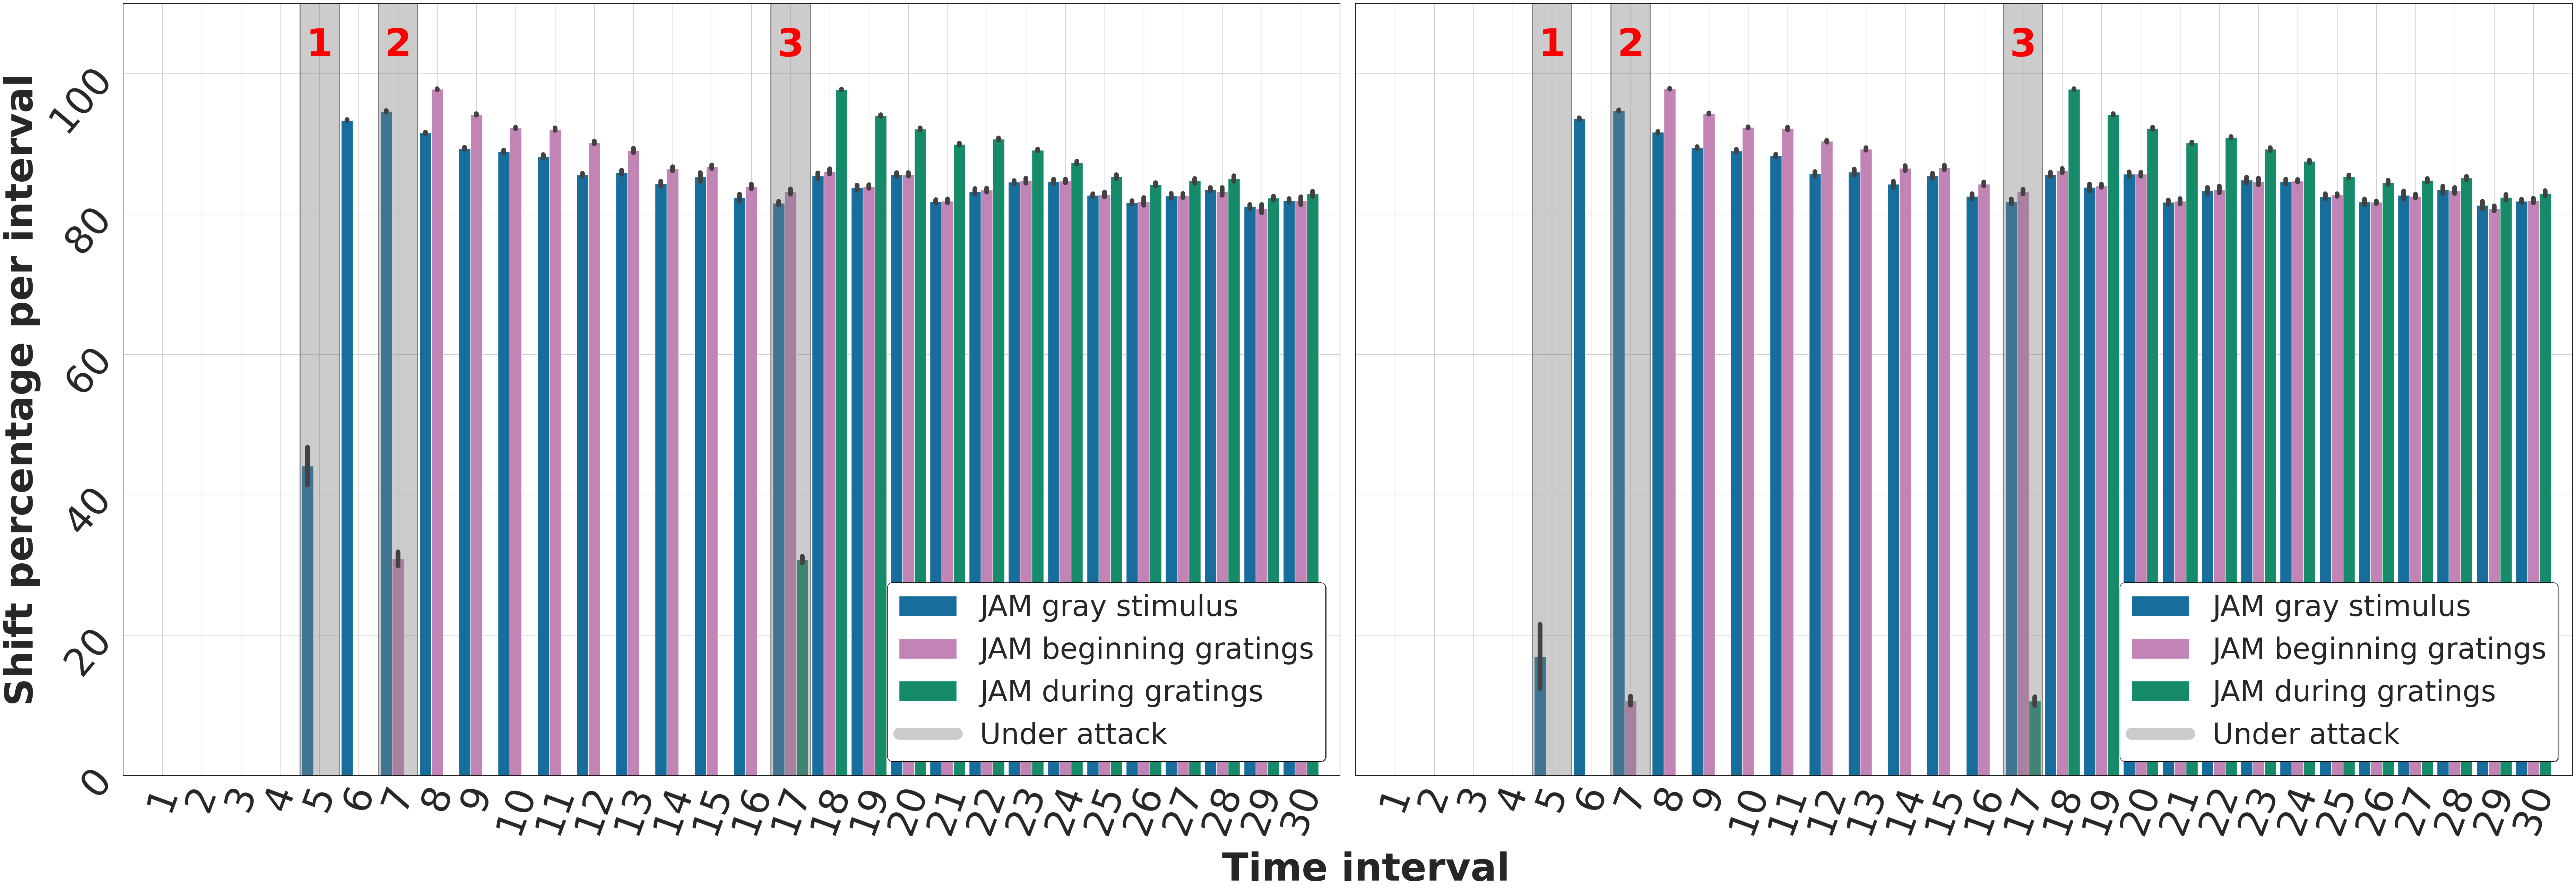

In [10]:
plot_percentage_shift_per_instant(df_shift_25,df_shift_50,'gratings')